**PART 1: SETUP, IMPORTS AND REPRODUCIBILITY**

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import timm
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import copy
import random
from tqdm import tqdm
import torch.nn.functional as F
from lime import lime_image
from skimage.segmentation import mark_boundaries
from PIL import Image
import torch

# Global Seed for Reproducibility
def seed_everything(seed=44):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")

Using Device: cuda


**PART 2: DATA PREPARATION (SANITIZED)**

In [18]:
# Configuration
DATA_DIR = "/kaggle/input/cactus-final/Cactus_final"
IMAGE_SIZE = 256
BATCH_SIZE = 16 
EPOCHS = 30
NUM_CLASSES = 3
K_FOLDS = 3
LEARNING_RATE = 2e-4 

# 2. Separate Transforms (Fixes Data Leakage)
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    # Clean transform for Validation
    'val': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Load Dataset Twice
dataset_train = datasets.ImageFolder(DATA_DIR, transform=data_transforms['train'])
dataset_val   = datasets.ImageFolder(DATA_DIR, transform=data_transforms['val'])

class_names = dataset_train.classes
targets = dataset_train.targets
print(f"Classes: {class_names}")
print(f"Total Images: {len(targets)}")

Classes: ['Affected', 'Healthy', 'No cactus']
Total Images: 3587


**PART 3: TRAINING LOOP**

In [19]:
# Helper function for training one epoch
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, correct / total

# Helper function for validation
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / total, correct / total

# K-Fold Loop
kfold = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
fold_results = []
best_global_acc = 0.0

print(f"\nStarting {K_FOLDS}-Fold Cross-Validation with MobileViT-XS...")

for fold, (train_idx, val_idx) in enumerate(kfold.split(np.zeros(len(targets)), targets)):
    print(f"\n--- Fold {fold+1}/{K_FOLDS} ---")
    
    # Creating Subsets from CORRECT Datasets
    train_subset = Subset(dataset_train, train_idx) 
    val_subset   = Subset(dataset_val, val_idx)     
    
    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader   = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    
    # Initialize Model
    model = timm.create_model('mobilevit_xs', pretrained=True, num_classes=NUM_CLASSES)
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.05)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    
    best_fold_acc = 0.0
    
    for epoch in range(EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)
        scheduler.step()
        
        if val_acc > best_fold_acc:
            best_fold_acc = val_acc
            if val_acc > best_global_acc:
                best_global_acc = val_acc
                torch.save(model.state_dict(), "best_mobilevit_xs_clean.pth")
                
    print(f"Fold {fold+1} Best Accuracy: {best_fold_acc:.4f}")
    fold_results.append(best_fold_acc)

# 5. Scientific Reporting
mean_acc = np.mean(fold_results)
std_acc = np.std(fold_results)
print(f"\n=== Final Results ===")
print(f"Mean Cross-Validation Accuracy: {mean_acc:.4f} (+/- {std_acc:.4f})")
print(f"Best Single Model Accuracy: {best_global_acc:.4f}")


Starting 3-Fold Cross-Validation with MobileViT-XS...

--- Fold 1/3 ---


Fold 1 Best Accuracy: 0.9749

--- Fold 2/3 ---


Fold 2 Best Accuracy: 0.9741

--- Fold 3/3 ---


Fold 3 Best Accuracy: 0.9741

=== Final Results ===
Mean Cross-Validation Accuracy: 0.9744 (+/- 0.0004)
Best Single Model Accuracy: 0.9749


**PART 4: VISUALIZATION (Using Best Model)**

Generating Metrics: 100%|██████████| 75/75 [00:03<00:00, 19.24it/s]


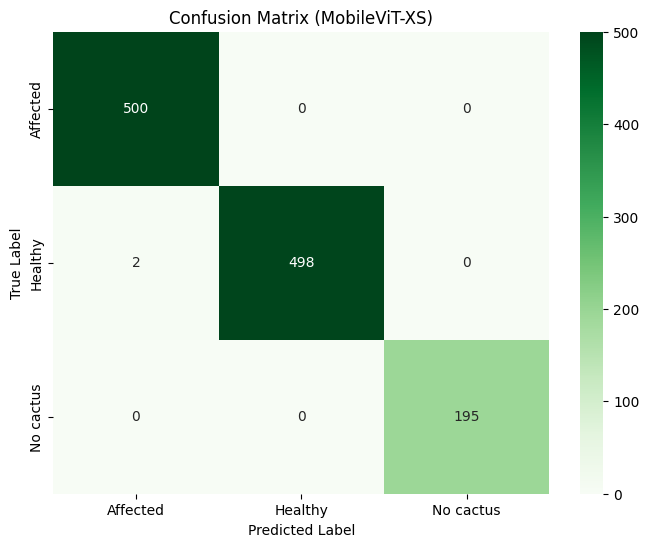

              precision    recall  f1-score   support

    Affected       1.00      1.00      1.00       500
     Healthy       1.00      1.00      1.00       500
   No cactus       1.00      1.00      1.00       195

    accuracy                           1.00      1195
   macro avg       1.00      1.00      1.00      1195
weighted avg       1.00      1.00      1.00      1195



In [20]:
# Load best model
final_model = timm.create_model('mobilevit_xs', pretrained=False, num_classes=NUM_CLASSES)
final_model.load_state_dict(torch.load("best_mobilevit_xs_clean.pth"))
final_model = final_model.to(device)
final_model.eval()

# Using the last validation fold as a proxy for the confusion matrix
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Generating Metrics"):
        images = images.to(device)
        outputs = final_model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (MobileViT-XS)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))

**PART 5: EXPLAINABILITY (LIME)**


--- Generating LIME Explanations ---
Class Mappings: {'Affected': 0, 'Healthy': 1, 'No cactus': 2}
Explaining Image: /kaggle/input/cactus-final/Cactus_final/Affected/cactus_affected_1.png
True Class: Affected


  0%|          | 0/1000 [00:00<?, ?it/s]

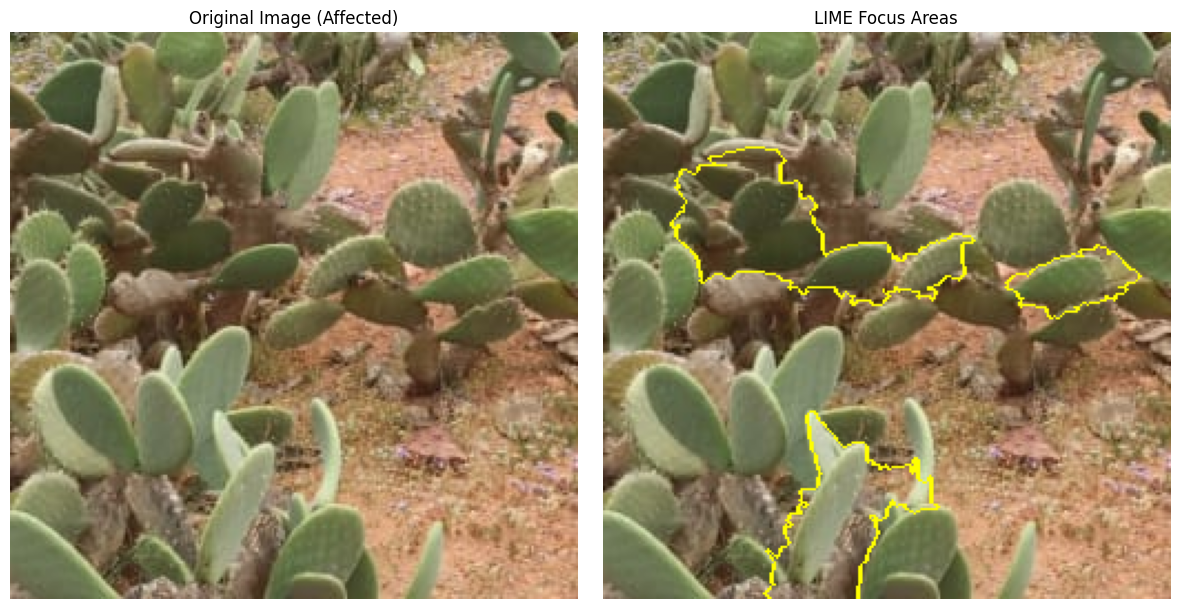

In [21]:
print("\n--- Generating LIME Explanations ---")

# 1. Setup Class Mappings
class_to_label = dataset_val.class_to_idx 
print(f"Class Mappings: {class_to_label}")

def predict_fn(images):
    final_model.eval()
    
    # Standard ImageNet Normalization
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)
    
    batch_tensors = []
    for img in images:
        # 1. Convert Numpy -> Tensor and Move to DEVICE immediately
        tensor_img = torch.tensor(img).permute(2, 0, 1).float().to(device)
        
        # 2. Normalize (Now both tensors are on the same device)
        tensor_img = (tensor_img - mean) / std
        batch_tensors.append(tensor_img)
        
    # Stack into a batch
    batch_tensor = torch.stack(batch_tensors)
    
    with torch.no_grad():
        logits = final_model(batch_tensor)
        probs = F.softmax(logits, dim=1)
        
    return probs.cpu().numpy()

# 3. Initialize LIME
explainer = lime_image.LimeImageExplainer()

# 4. Select an Image to Explain
target_class = 'Affected'
target_idx = class_to_label[target_class]

# Find indices in validation set
indices = [i for i, label in enumerate(all_labels) if label == target_idx]

if len(indices) > 0:
    test_idx = indices[0] 
    
    # Retrieve original image
    subset_idx = val_subset.indices[test_idx]
    img_path, true_label_idx = dataset_val.samples[subset_idx]
    
    print(f"Explaining Image: {img_path}")
    print(f"True Class: {class_names[true_label_idx]}")

    # Load image for LIME
    original_img = Image.open(img_path).convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
    original_array = np.array(original_img) / 255.0 

    # 5. Generate Explanation
    explanation = explainer.explain_instance(
        original_array.astype('double'), 
        predict_fn, 
        top_labels=3, 
        hide_color=0, 
        num_samples=1000 
    )

    # 6. Visualize
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0], 
        positive_only=True, 
        num_features=5, 
        hide_rest=False
    )

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(original_array)
    plt.title(f'Original Image ({target_class})')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(mark_boundaries(temp, mask))
    plt.title(f'LIME Focus Areas')
    plt.axis('off')
    
    plt.tight_layout()
    plt.savefig('lime_explanation.png', dpi=300)
    plt.show()
    
else:
    print(f"No images found for class {target_class} in the validation set.")